In [1]:
import operator
from typing import TypedDict, List, Annotated, Union, Literal
from langchain_core.messages import HumanMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=1.0)

In [3]:
class AgentState(TypedDict):
    messages: Annotated[List[Union[HumanMessage, AIMessage]], operator.add]

In [4]:
def call_llm(state: AgentState) -> dict:
    """call the llm to answer the user"""
    if not state["messages"]:
        return {}

    print(f"calling call_llm with state {state}")

    response = model.invoke(state["messages"])

    ai_message = AIMessage(content=response.content)

    return {"messages": [ai_message]}

def get_user_message(state: AgentState) -> dict:
    """get the user message"""

    print(f"calling get_user_message with state {state}")

    user_input = input("Enter your message: ")
    human_message = HumanMessage(content=user_input)

    return {"messages": [human_message]}

def should_continue(state: AgentState) -> Literal["continue", "break"]:
    return "break" if not state["messages"] or state["messages"][-1].content == "quit" else "continue"


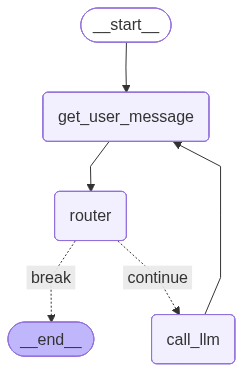

In [8]:
graph = StateGraph(AgentState)
graph.add_node("call_llm", call_llm)
graph.add_node("get_user_message", get_user_message)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "get_user_message")
graph.add_edge("call_llm", "get_user_message")

graph.add_conditional_edges(
    "router",
    should_continue,
    {
        "continue":"call_llm",
        "break":END
    })


graph.add_edge("get_user_message", "router")
agent = graph.compile()

agent

In [9]:
agent.invoke({})

calling get_user_message with state {'messages': []}
calling call_llm with state {'messages': [HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={}), HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={})]}
calling get_user_message with state {'messages': [HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={}), HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={}), AIMessage(content='I can answer questions, generate text, translate languages, write different kinds of creative content, and assist with tasks.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}
calling call_llm with state {'messages': [HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={}), HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadat

{'messages': [HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={}),
  AIMessage(content='I can answer questions, generate text, translate languages, write different kinds of creative content, and assist with tasks.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='what else\n', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='what can you do in few words', additional_kwargs={}, response_metadata={}),
  AIMessage(content='I can answer questions, generate text, translate languages, write different kinds of creative content, and assist with tasks.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='what else\n', add